#### The mass distirbutions of the binary white dwarf (WDWD) and binary neutron star (NSNS) systems that merge within a Hubble Time and their progenitors

### Imports and definitions

In [1]:
import h5py as h5 
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import tol_colors as tc

import useful_fncs
import utils_from_others
import figure_utils

# plotting imports
# import for axes labels 
plt.rc('text.latex', preamble=r'\usepackage{textgreek}')
plt.rc('font', family='serif')
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif"
})

### Read in Data

Let's first read in the NSNS data

In [2]:
## NSNS optimized run

# let's first look at the NSNS_output
pathToH5_NSNS = '/expanse/lustre/scratch/msantiago/temp_project/v03.21.00/COMPAS_DATA/v03.21.00/N5e6_NSNS_fid/MainRun/COMPAS_Output_wWeights.h5'

Data_NSNS  = h5.File(pathToH5_NSNS, "r")

DCOs_NSNS = Data_NSNS['BSE_Double_Compact_Objects'] # getting the DCO objects

# gathering the double compact objects that we have computed rates for
DCO_mask_NSNS = Data_NSNS['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['DCOmask'][()]

DATA_SPS_NSNS = Data_NSNS['BSE_System_Parameters']

In [3]:
# merges in a Hubble Time
# times (these should be in Myr)
lifetimes_all = DCOs_NSNS['Time'][()]
lifetimes_DCO = lifetimes_all[DCO_mask_NSNS]

col_times_all = DCOs_NSNS['Coalescence_Time'][()]
col_times_DCO = col_times_all[DCO_mask_NSNS]

delay_times_DCO = lifetimes_DCO + col_times_DCO
condition_mergers = delay_times_DCO < 13800 # Myr

stellar_types_all_1 = DCOs_NSNS['Stellar_Type(1)'][()]
stellar_types_1_DCO = stellar_types_all_1[DCO_mask_NSNS]
stellar_types_1_merged = stellar_types_1_DCO[condition_mergers]

stellar_types_all_2 = DCOs_NSNS['Stellar_Type(2)'][()]
stellar_types_2_DCO = stellar_types_all_2[DCO_mask_NSNS]
stellar_types_2_merged = stellar_types_2_DCO[condition_mergers]

stellar_types_all_1 = DCOs_NSNS['Stellar_Type(1)'][()]
stellar_types_1_DCO = stellar_types_all_1[DCO_mask_NSNS]
stellar_types_1_merged = stellar_types_1_DCO[condition_mergers]

# gathering the masses
mass_1_all_NSNS = DCOs_NSNS['Mass(1)'][()]
mass_1_DCO_NSNS = mass_1_all_NSNS[DCO_mask_NSNS]
mass_1_merged_NSNS = mass_1_DCO_NSNS[condition_mergers]

mass_2_all_NSNS = DCOs_NSNS['Mass(2)'][()]
mass_2_DCO_NSNS = mass_2_all_NSNS[DCO_mask_NSNS]
mass_2_merged_NSNS = mass_2_DCO_NSNS[condition_mergers]

# we are going to conditions that M1>M2 (not considering mass ratio reversal cases)
M1_NSNS = np.maximum(mass_1_merged_NSNS, mass_2_merged_NSNS)
M2_NSNS = np.minimum(mass_1_merged_NSNS, mass_2_merged_NSNS)

# gathering the mixture weight info
mixture_weights_all = DCOs_NSNS['mixture_weight'][()]
mixtrue_weights_dco = mixture_weights_all[DCO_mask_NSNS]
mixtrue_weights_merged = mixtrue_weights_dco[condition_mergers]

In [4]:
# bool for just the NSNS systems
NSNS_systems_bool = np.logical_and(stellar_types_1_merged==13, stellar_types_2_merged==13)

In [5]:
rates_z0_DCO_NSNS = Data_NSNS['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['merger_rate_z0'][()]
rates_z0_merged_hubble = rates_z0_DCO_NSNS[condition_mergers]
rates_z0_merged_NSNS = rates_z0_merged_hubble[NSNS_systems_bool]

We are going to read in data about the WDWD systems that could possibly represent the double degenerate scenario of Type Ia Supernovae. We will use the WDWD optimized run to gather this information. Our conditions for the general double degenerate case is:

1) two white dwarfs, with at least being a carbon/oxygen WD (COWD)
2) merge within a Hubble Time

In [6]:
## WDWD optimized run
pathToH5_WDWD = '/expanse/lustre/scratch/msantiago/temp_project/v03.21.00/COMPAS_DATA/v03.21.00/N5e6_MassiveWDWD_NSNS_fid/MainRun/COMPAS_Output_wWeights.h5'

Data_WDWD  = h5.File(pathToH5_WDWD, "r")

DCOs_WDWD = Data_WDWD['BSE_Double_Compact_Objects'] # getting the DCO objects

# gathering the double compact objects that we have computed rates for
DCO_mask_WDWD = Data_WDWD['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['DCOmask'][()]

DATA_SPS_WDWD = Data_WDWD['BSE_System_Parameters']

In [7]:
# merges in a Hubble Time
# times (these should be in Myr)
lifetimes_all_DWD = DCOs_WDWD['Time'][()]
lifetimes_DCO_DWD = lifetimes_all_DWD[DCO_mask_WDWD]

col_times_all_DWD = DCOs_WDWD['Coalescence_Time'][()]
col_times_DCO_DWD = col_times_all_DWD[DCO_mask_WDWD]

delay_times_DCO_DWD = lifetimes_DCO_DWD + col_times_DCO_DWD
condition_mergers_WDopt = delay_times_DCO_DWD < 13800 # Myr

# Merges_Hubble_Time_WDopt = Data_WDWD['BSE_Double_Compact_Objects']['Merges_Hubble_Time'][()]
# Merges_Hubble_Time_DCO_WDopt = Merges_Hubble_Time_WDopt[DCO_mask_WDWD]
# condition_mergers_WDopt = Merges_Hubble_Time_DCO_WDopt == True

stellar_types_all_1_WDopt = DCOs_WDWD['Stellar_Type(1)'][()]
stellar_types_1_DCO_WDopt = stellar_types_all_1_WDopt[DCO_mask_WDWD]
stellar_types_1_merged_WDopt = stellar_types_1_DCO_WDopt[condition_mergers_WDopt]

stellar_types_all_2 = DCOs_WDWD['Stellar_Type(2)'][()]
stellar_types_2_DCO = stellar_types_all_2[DCO_mask_WDWD]
stellar_types_2_merged_WDopt = stellar_types_2_DCO[condition_mergers_WDopt]

# gathering the masses
mass_1_all = DCOs_WDWD['Mass(1)'][()]
mass_1_DCO = mass_1_all[DCO_mask_WDWD]
mass_1_merged = mass_1_DCO[condition_mergers_WDopt]

mass_2_all = DCOs_WDWD['Mass(2)'][()]
mass_2_DCO = mass_2_all[DCO_mask_WDWD]
mass_2_merged = mass_2_DCO[condition_mergers_WDopt]

# we are going to conditions that M1>M2 (not considering mass ratio reversal cases)
M1_DWD = np.maximum(mass_1_merged, mass_2_merged)
M2_DWD = np.minimum(mass_1_merged, mass_2_merged)

# gathering the mixture weight info
mixture_weights_all_WDopt = DCOs_WDWD['mixture_weight'][()]
mixtrue_weights_dco_WDopt = mixture_weights_all_WDopt[DCO_mask_WDWD]
mixtrue_weights_merged_WDopt = mixtrue_weights_dco_WDopt[condition_mergers_WDopt]

In [8]:
# let's find the bools for each of our progenitor systems

# WDWD bool with at least one COWD + COWD/HeWD
HeWD_bool_WDWD,COWD_bool_WDWD,ONeWD_bool_WDWD,HeCOWD_bool_WDWD,HeONeWD_bool_WDWD,COHeWD_bool_WDWD,COONeWD_bool_WDWD,ONeHeWD_bool_WDWD,ONeCOWD_bool_WDWD = useful_fncs.WD_BINARY_BOOLS(stellar_types_1_merged_WDopt, stellar_types_2_merged_WDopt)
carbon_oxygen_bool_WDWD_merged_WDopt = np.logical_or(ONeCOWD_bool_WDWD,np.logical_or(COONeWD_bool_WDWD,np.logical_or(COHeWD_bool_WDWD,np.logical_or(COWD_bool_WDWD,HeCOWD_bool_WDWD))))

# COWD + COWD/HeWD with Mchan > 1.4
tot_mass_cond = mass_1_merged + mass_2_merged > 1.4
super_chan_bool = carbon_oxygen_bool_WDWD_merged_WDopt*tot_mass_cond

# violent merger - unequal mass + COWD+COWD
mass_unequal_conditon = M1_DWD >= 1.1
violent_merger_unequal_bool = mass_unequal_conditon*COWD_bool_WDWD

# violent merger - equal mass (q_cr = 0.9) + COWD+COWD
mass_min_criteria = M1_DWD>=0.8
critical_mass_ratio_bool = np.logical_and(M2_DWD/M1_DWD >= 0.9, mass_min_criteria)
violent_merger_equal_bool = critical_mass_ratio_bool*COWD_bool_WDWD

# D6 HVS
SN_Ia_HVS,two_star_SNIA,Champagne_Supernova = useful_fncs.check_if_SNIA(mass_1_merged[carbon_oxygen_bool_WDWD_merged_WDopt], mass_2_merged[carbon_oxygen_bool_WDWD_merged_WDopt])

# # D6 - two explosion
# mass_D6_condition = mass_1_merged < 1.0
# d6_two_explosion = mass_D6_condition*carbon_oxygen_bool_WDWD_merged_WDopt


In [9]:
rates_z0_DCO = Data_WDWD['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['merger_rate_z0'][()]
rates_z0_merged = rates_z0_DCO[condition_mergers_WDopt]
rates_z0_merged_COWD = rates_z0_merged[carbon_oxygen_bool_WDWD_merged_WDopt]

In [10]:
rates_z0_violent_merger_unequal = rates_z0_merged[violent_merger_unequal_bool]
rates_z0_violent_merger_equal = rates_z0_merged[violent_merger_equal_bool]
rates_z0_super_chan = rates_z0_merged[super_chan_bool]
rates_z0_HVS = rates_z0_merged_COWD[SN_Ia_HVS]
# rates_z0_D6_twoexplosion = rates_z0_merged[d6_two_explosion]

### Plotting

Text(0.5, 1.0, 'Fiducial: NSNS Mass Distribution')

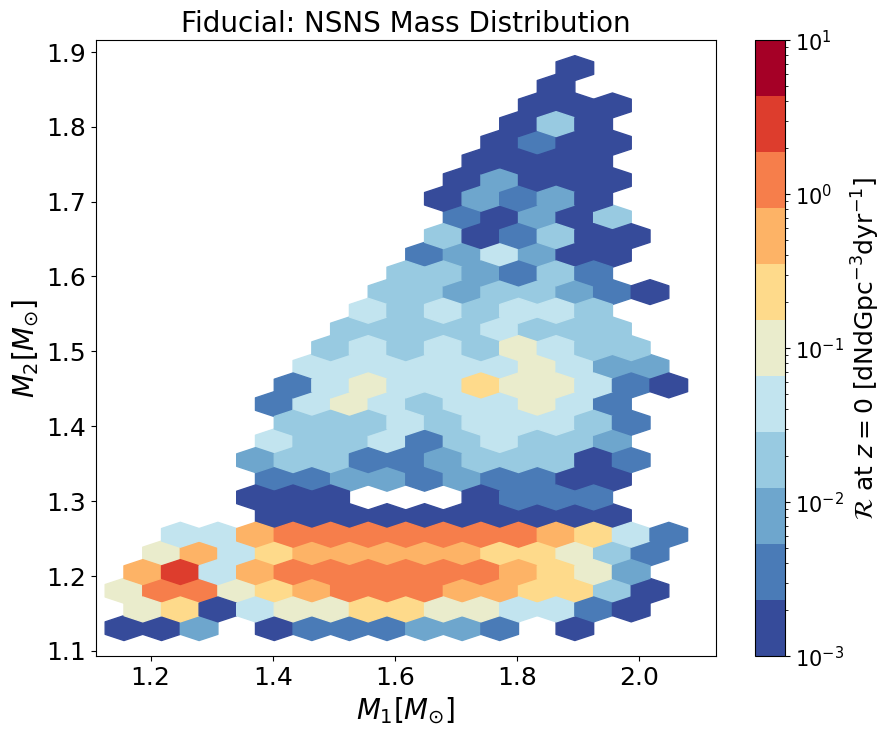

In [16]:
# NSNS

fig, ax = plt.subplots(figsize = (10,8))

# cset = tc.sunset_


vmin = 10**-3
vmax = 10**1

M1 = M1_NSNS[NSNS_systems_bool]
M2 = M2_NSNS[NSNS_systems_bool]

hb = ax.hexbin(M1,M2,C=rates_z0_merged_NSNS, gridsize=(15,15), reduce_C_function = np.sum, 
                    cmap="tol.sunset_discrete",norm='log',vmin=vmin,vmax=vmax) # C is how much each point is weighted

cb = plt.colorbar(hb)
cb.set_label(label=r"$\mathcal{R}$ at $z=0$ [$\mathrm{dNdGpc^{-3}dyr^{-1}}$]", fontsize = 18)
cb.ax.tick_params(labelsize=15)

max_mass_lim = 1.44

# linecolors = 'white'
# linewidths = 4

# ax.axline((0,0), (max(M1),max(M1)), color=linecolors, ls='--', lw=linewidths, transform=plt.gca().transAxes)

# #Helium WD cutoff
# ax.vlines(x=[0.45], ymin=0, ymax=0.45, colors=linecolors, ls='--', lw=linewidths) # vertical line
# ax.plot([0.45,max_mass_lim],[0.45,0.45],color=linecolors,lw=linewidths, ls='--') # horizontal line

# #Carbon oxygen WD cutoff
# ax.vlines(x=[1.1], ymin=0, ymax=1.1, colors=linecolors, ls='--', lw=linewidths) # vertical line
# ax.plot([1.1,max_mass_lim],[1.1,1.1],color=linecolors,lw=linewidths, ls='--') # horizontal line

# # purple region - 2 star SN Ia
# ax.plot([0.8,1],[0.8,0.44],color='purple') # bottom boundary
# ax.plot([1.0,1.0],[1.0,0.44],color='purple') # side boundary
# ax.plot([0.8,1.0],[0.8,1.0],color='purple',ls='--') # top boundary 

# # red region - hypervelocity WDs
# plt.plot([0.8,1],[0.8,0.44],color='red',ls='--') # overlapping boundary
# plt.plot([0.75,1.0],[0.75,0.3],color='red') # bottom boundary
# plt.plot([1.0,1.0],[0.3,0.44],color='red') # side boundary
# plt.plot([0.75,0.8],[0.75,0.8],color='red',ls='--') # top boundary

# # # chandrasekar mass line
# ax.plot((1.44,0.7),(0,0.7),color='black', lw=3, ls='--', alpha = 0.4)

# ax.set_ylim(min(M2),max_mass_lim)
# ax.set_xlim(min(M2),max_mass_lim)
ax.set_xlabel("$M_{1}$[$M_{\odot}$]",fontsize=20)
ax.set_ylabel("$M_{2}$[$M_{\odot}$]",fontsize=20)
ax.tick_params(axis='both', labelsize=18)

ax.set_title("Fiducial: NSNS Mass Distribution", fontsize=20)

## save figure:
# plt.savefig("../figures/mass_dist_NSNS.png",bbox_inches='tight',pad_inches=0.1)

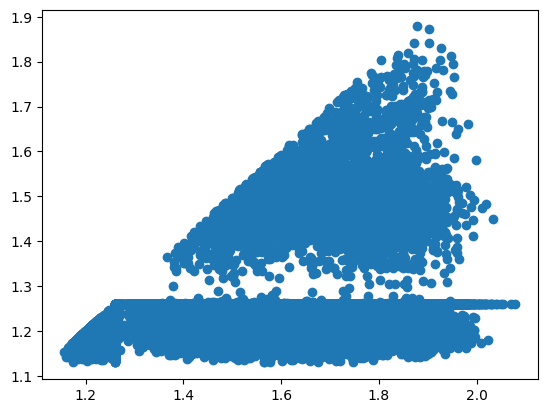

In [13]:
plt.scatter(M1, M2)

Text(0.5, 1.0, 'Fiducial: DWD Mass Distribution')

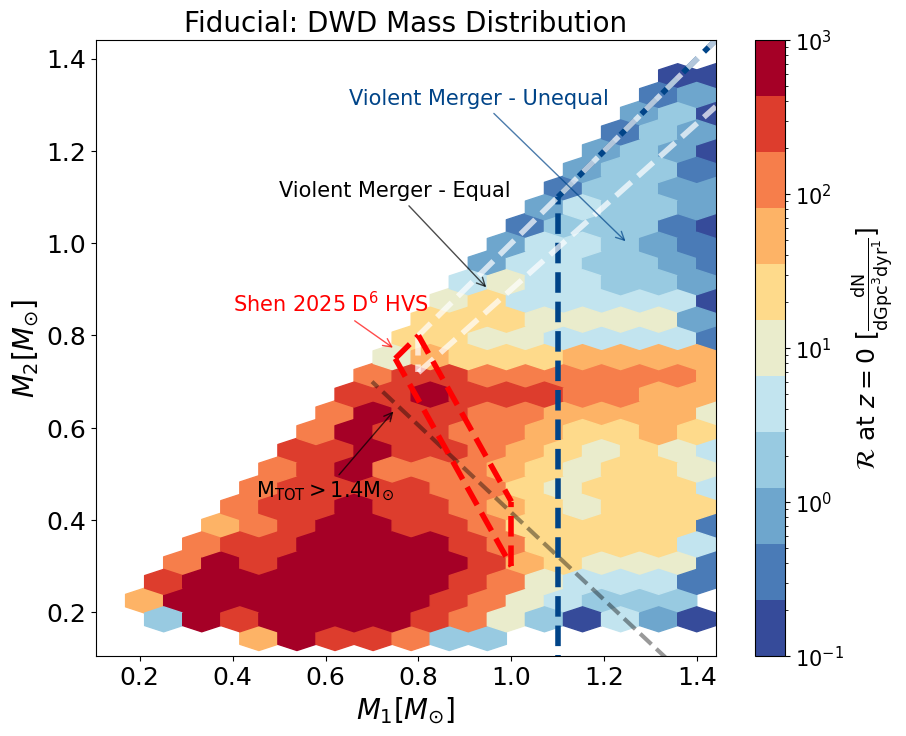

In [14]:
# DWD

fig, ax = plt.subplots(figsize = (10,8))

cset_c = tc.medium_contrast


vmin = 10**-1
vmax = 10**3

M1_COWD = M1_DWD[carbon_oxygen_bool_WDWD_merged_WDopt]
M2_COWD = M2_DWD[carbon_oxygen_bool_WDWD_merged_WDopt]

hb = ax.hexbin(M1_COWD,M2_COWD,C=rates_z0_merged_COWD, gridsize=(15,15), reduce_C_function = np.sum, 
                    cmap="tol.sunset_discrete",norm='log',vmin=vmin,vmax=vmax) # C is how much each point is weighted

cb = plt.colorbar(hb)
cb.set_label(label=r"$\mathcal{R}$ at $z=0$ [$\frac{\mathrm{dN}}{\mathrm{dGpc^{3}dyr^{1}}}$]", fontsize = 18)
cb.ax.tick_params(labelsize=15)

max_mass_lim = 1.44

linecolors = 'white'
linewidths = 4

# ax.axline((0,0), (max(M1_DWD),max(M1_DWD)), color=linecolors, ls='--', lw=linewidths, transform=plt.gca().transAxes)

# #Helium WD cutoff
# ax.vlines(x=[0.45], ymin=0, ymax=0.45, colors=linecolors, ls='--', lw=linewidths) # vertical line
# ax.plot([0.45,max_mass_lim],[0.45,0.45],color=linecolors,lw=linewidths, ls='--') # horizontal line

# #Carbon oxygen WD cutoff
# ax.vlines(x=[1.1], ymin=0, ymax=1.1, colors=linecolors, ls='--', lw=linewidths) # vertical line
# ax.plot([1.1,max_mass_lim],[1.1,1.1],color=linecolors,lw=linewidths, ls='--') # horizontal line

# # purple region - 2 star SN Ia
# ax.plot([0.8,1],[0.8,0.44],color='purple') # bottom boundary
# ax.plot([1.0,1.0],[1.0,0.44],color='purple') # side boundary
# ax.plot([0.8,1.0],[0.8,1.0],color='purple',ls='--') # top boundary 


# # chandrasekar mass line
ax.plot((1.44,0.7),(0,0.7),color='black', lw=3, ls='--', alpha = 0.4)
ax.annotate(r"$\rm{M}_{\rm{TOT}}>1.4\rm{M}_{\odot}$", xy=(0.75, 0.64), xytext=(0.45, 0.45), fontsize=15, color='black', arrowprops=dict(alpha=0.7,arrowstyle='->'))

# # violent merger - unequal
# mass_unequal_conditon = np.logical_and(M1_DWD >= 1.1, M2_DWD!=M1_DWD)
# violent_merger_unequal_bool = mass_unequal_conditon*COWD_bool_WDWD
# ax.scatter(M1_DWD[violent_merger_unequal_bool], M2_DWD[violent_merger_unequal_bool], color=cset_c.dark_blue)

ax.vlines(x=[1.1], ymin=0, ymax=1.1, colors=cset_c.dark_blue, ls='--', lw=linewidths) # vertical line
ax.plot([1.1,max_mass_lim],[1.1,max_mass_lim],color=cset_c.dark_blue,lw=linewidths, ls='--') # horizontal line
ax.annotate(r"Violent Merger - Unequal", xy=(1.25, 1), xytext=(0.65, 1.3), fontsize=15, color=cset_c.dark_blue, arrowprops=dict(color=cset_c.dark_blue,alpha=0.7,arrowstyle='->'))


# # violent merger - equal
# mass_min_criteria = M1_DWD>=0.8
# critical_mass_ratio_bool = np.logical_and(M2_DWD/M1_DWD >= 0.9, mass_min_criteria)
# violent_merger_equal_bool = critical_mass_ratio_bool*COWD_bool_WDWD
# ax.scatter(M1_DWD[violent_merger_equal_bool], M2_DWD[violent_merger_equal_bool], color='white', alpha=0.7)

ax.plot([0.75,max_mass_lim],[0.75,max_mass_lim],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # top boundary
ax.plot([0.8,max_mass_lim],[0.72,max_mass_lim*0.9],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # bottom boundary
ax.plot([0.8,0.8],[0.8,0.72],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # side boundary
ax.annotate(r"Violent Merger - Equal", xy=(0.95, 0.9), xytext=(0.5, 1.1), fontsize=15, color='black', arrowprops=dict(color='black',alpha=0.7,arrowstyle='->'))



# # red region - hypervelocity WDs
# SN_Ia_HVS,two_star_SNIA,Champagne_Supernova = useful_fncs.check_if_SNIA(M1_COWD, M2_COWD)
# ax.scatter(M1_COWD[SN_Ia_HVS], M2_COWD[SN_Ia_HVS])

ax.plot([0.8,1],[0.8,0.44],color='red',ls='--', lw=4) # overlapping boundary
ax.plot([0.75,1.0],[0.75,0.3],'red', ls='--', lw=4) # bottom boundary
ax.plot([1.0,1.0],[0.3,0.44],'red', ls='--', lw=4) # side boundary
ax.plot([0.75,0.8],[0.75,0.8],'red',ls='--', lw=4) # top boundary
ax.annotate(r"Shen 2025 $\mathrm{D^6}$ HVS", xy=(0.75, 0.77), xytext=(0.4, 0.85), fontsize=15, color='red', arrowprops=dict(color='red', alpha=0.7,arrowstyle='->'))

ax.set_ylim(min(M2_DWD),max_mass_lim)
ax.set_xlim(min(M2_DWD),max_mass_lim)
ax.set_xlabel("$M_{1}$[$M_{\odot}$]",fontsize=20)
ax.set_ylabel("$M_{2}$[$M_{\odot}$]",fontsize=20)
ax.tick_params(axis='both', labelsize=18)

ax.set_title("Fiducial: DWD Mass Distribution", fontsize=20)

## save figure:
# plt.savefig("../figures/mass_dist_DWD_scenarios.png",bbox_inches='tight',pad_inches=0.1)

In [18]:
Data_NSNS.close()
Data_WDWD.close()

### Let's look at this mass distribution at different redshift snapshots

In [15]:
rates_DCO_NSNS = np.array(Data_NSNS['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['merger_rate'][()])

In [16]:
redshifts_NSNS = Data_NSNS['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['redshifts'][()]

In [17]:
rates_DCO_WDWD = np.array(Data_WDWD['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['merger_rate'][()])

In [25]:
redshift_index_2 = np.where(redshifts_NSNS ==2.)[0][0]
rates_WDWD_z2 = rates_DCO_WDWD[:,redshift_index_2]
rates_WDWD_z2_merged = rates_WDWD_z2[condition_mergers_WDopt]
rates_WDWD_z2_COWD = rates_WDWD_z2_merged[carbon_oxygen_bool_WDWD_merged_WDopt]

redshift_index_3 = np.where(redshifts_NSNS ==3.)[0][0]
rates_WDWD_z3 = rates_DCO_WDWD[:,redshift_index_3]
rates_WDWD_z3_merged = rates_WDWD_z3[condition_mergers_WDopt]
rates_WDWD_z3_COWD = rates_WDWD_z3_merged[carbon_oxygen_bool_WDWD_merged_WDopt]

redshift_index_4 = np.where(redshifts_NSNS ==4.)[0][0]
rates_WDWD_z4 = np.array(rates_DCO_WDWD[:,redshift_index_4])
rates_WDWD_z4_merged = rates_WDWD_z4[condition_mergers_WDopt]
rates_WDWD_z4_COWD = rates_WDWD_z4_merged[carbon_oxygen_bool_WDWD_merged_WDopt]

redshift_index_6 = np.where(redshifts_NSNS ==6.)[0][0]
rates_WDWD_z6 = rates_DCO_WDWD[:,redshift_index_6]
rates_WDWD_z6_merged = rates_WDWD_z6[condition_mergers_WDopt]
rates_WDWD_z6_COWD = rates_WDWD_z6_merged[carbon_oxygen_bool_WDWD_merged_WDopt]

redshift_index_65 = np.where(redshifts_NSNS ==6.5)[0][0]
rates_WDWD_z65 = rates_DCO_WDWD[:,redshift_index_65]
rates_WDWD_z65_merged = rates_WDWD_z65[condition_mergers_WDopt]
rates_WDWD_z65_COWD = rates_WDWD_z65_merged[carbon_oxygen_bool_WDWD_merged_WDopt]

redshift_index_7 = np.where(redshifts_NSNS ==7.)[0][0]
rates_WDWD_z7 = np.array(rates_DCO_WDWD[:,redshift_index_7])
rates_WDWD_z7_merged = rates_WDWD_z7[condition_mergers_WDopt]
rates_WDWD_z7_COWD = rates_WDWD_z7_merged[carbon_oxygen_bool_WDWD_merged_WDopt]

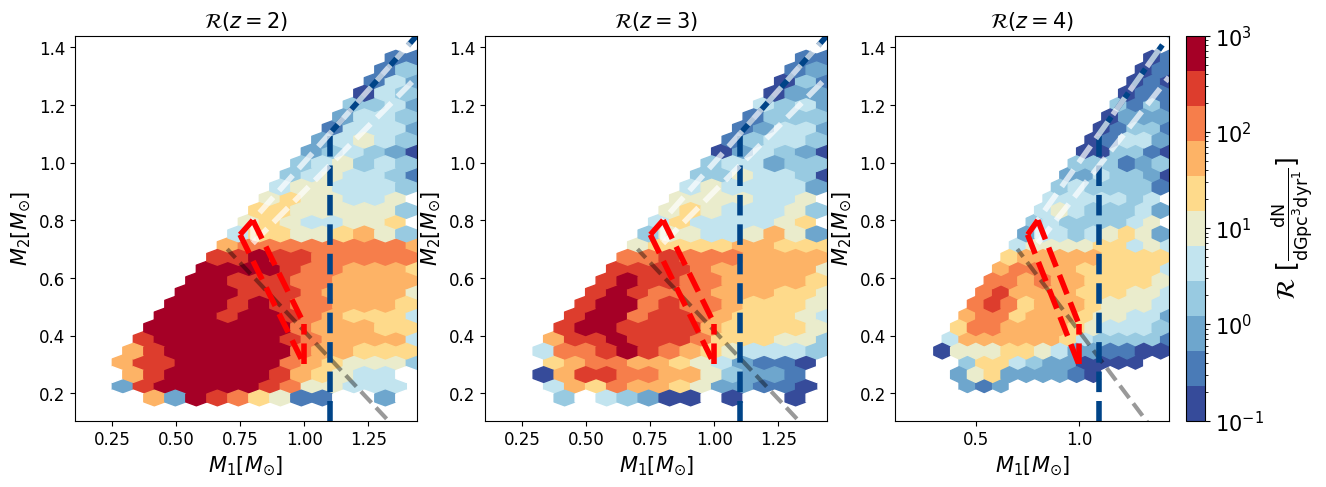

In [33]:
# DWD

fig, ax = plt.subplots(1,3, figsize = (15,5))

cset_c = tc.medium_contrast


vmin = 10**-1
vmax = 10**3

M1_COWD = M1_DWD[carbon_oxygen_bool_WDWD_merged_WDopt]
M2_COWD = M2_DWD[carbon_oxygen_bool_WDWD_merged_WDopt]

hb_2 = ax[0].hexbin(M1_COWD,M2_COWD,C=rates_WDWD_z2_COWD, gridsize=(15,15), reduce_C_function = np.sum, 
                    cmap="tol.sunset_discrete",norm='log',vmin=vmin,vmax=vmax) # C is how much each point is weighted

hb_3 = ax[1].hexbin(M1_COWD,M2_COWD,C=rates_WDWD_z3_COWD, gridsize=(15,15), reduce_C_function = np.sum, 
                    cmap="tol.sunset_discrete",norm='log',vmin=vmin,vmax=vmax) # C is how much each point is weighted

hb_4 = ax[2].hexbin(M1_COWD,M2_COWD,C=rates_WDWD_z4_COWD, gridsize=(15,15), reduce_C_function = np.sum, 
                    cmap="tol.sunset_discrete",norm='log',vmin=vmin,vmax=vmax) # C is how much each point is weighted


cb_4 = plt.colorbar(hb_4)
cb_4.set_label(label=r"$\mathcal{R}$ [$\frac{\mathrm{dN}}{\mathrm{dGpc^{3}dyr^{1}}}$]", fontsize = 18)
cb_4.ax.tick_params(labelsize=15)

max_mass_lim = 1.44

linecolors = 'white'
linewidths = 4


# # chandrasekar mass line
ax[0].plot((1.44,0.7),(0,0.7),color='black', lw=3, ls='--', alpha = 0.4)
# ax[0].annotate(r"$\rm{M}_{\rm{TOT}}>1.4\rm{M}_{\odot}$", xy=(0.75, 0.64), xytext=(0.45, 0.45), fontsize=11, color='black', arrowprops=dict(alpha=0.7,arrowstyle='->'))

# # violent merger - unequal
ax[0].vlines(x=[1.1], ymin=0, ymax=1.1, colors=cset_c.dark_blue, ls='--', lw=linewidths) # vertical line
ax[0].plot([1.1,max_mass_lim],[1.1,max_mass_lim],color=cset_c.dark_blue,lw=linewidths, ls='--') # horizontal line
# ax[0].annotate(r"Violent Merger - Unequal", xy=(1.25, 1), xytext=(0.65, 1.3), fontsize=11, color=cset_c.dark_blue, arrowprops=dict(color=cset_c.dark_blue,alpha=0.7,arrowstyle='->'))

# # violent merger - equal
ax[0].plot([0.75,max_mass_lim],[0.75,max_mass_lim],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # top boundary
ax[0].plot([0.8,max_mass_lim],[0.72,max_mass_lim*0.9],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # bottom boundary
ax[0].plot([0.8,0.8],[0.8,0.72],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # side boundary
# ax[0].annotate(r"Violent Merger - Equal", xy=(0.95, 0.9), xytext=(0.5, 1.1), fontsize=11, color='black', arrowprops=dict(color='black',alpha=0.7,arrowstyle='->'))

# Shen HVS SNe Ia
ax[0].plot([0.8,1],[0.8,0.44],color='red',ls='--', lw=4) # overlapping boundary
ax[0].plot([0.75,1.0],[0.75,0.3],'red', ls='--', lw=4) # bottom boundary
ax[0].plot([1.0,1.0],[0.3,0.44],'red', ls='--', lw=4) # side boundary
ax[0].plot([0.75,0.8],[0.75,0.8],'red',ls='--', lw=4) # top boundary
# ax[0].annotate(r"Shen 2025 $\mathrm{D^6}$ HVS", xy=(0.75, 0.77), xytext=(0.4, 0.85), fontsize=11, color='red', arrowprops=dict(color='red', alpha=0.7,arrowstyle='->'))





# # chandrasekar mass line
ax[1].plot((1.44,0.7),(0,0.7),color='black', lw=3, ls='--', alpha = 0.4)
# ax[1].annotate(r"$\rm{M}_{\rm{TOT}}>1.4\rm{M}_{\odot}$", xy=(0.75, 0.64), xytext=(0.45, 0.45), fontsize=15, color='black', arrowprops=dict(alpha=0.7,arrowstyle='->'))

# # violent merger - unequal
ax[1].vlines(x=[1.1], ymin=0, ymax=1.1, colors=cset_c.dark_blue, ls='--', lw=linewidths) # vertical line
ax[1].plot([1.1,max_mass_lim],[1.1,max_mass_lim],color=cset_c.dark_blue,lw=linewidths, ls='--') # horizontal line
# ax[1].annotate(r"Violent Merger - Unequal", xy=(1.25, 1), xytext=(0.65, 1.3), fontsize=11, color=cset_c.dark_blue, arrowprops=dict(color=cset_c.dark_blue,alpha=0.7,arrowstyle='->'))

# # violent merger - equal
ax[1].plot([0.75,max_mass_lim],[0.75,max_mass_lim],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # top boundary
ax[1].plot([0.8,max_mass_lim],[0.72,max_mass_lim*0.9],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # bottom boundary
ax[1].plot([0.8,0.8],[0.8,0.72],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # side boundary
# ax[1].annotate(r"Violent Merger - Equal", xy=(0.95, 0.9), xytext=(0.5, 1.1), fontsize=11, color='black', arrowprops=dict(color='black',alpha=0.7,arrowstyle='->'))

# Shen HVS SNe Ia
ax[1].plot([0.8,1],[0.8,0.44],color='red',ls='--', lw=4) # overlapping boundary
ax[1].plot([0.75,1.0],[0.75,0.3],'red', ls='--', lw=4) # bottom boundary
ax[1].plot([1.0,1.0],[0.3,0.44],'red', ls='--', lw=4) # side boundary
ax[1].plot([0.75,0.8],[0.75,0.8],'red',ls='--', lw=4) # top boundary
# ax[1].annotate(r"Shen 2025 $\mathrm{D^6}$ HVS", xy=(0.75, 0.77), xytext=(0.4, 0.85), fontsize=11, color='red', arrowprops=dict(color='red', alpha=0.7,arrowstyle='->'))




# # chandrasekar mass line
ax[2].plot((1.44,0.7),(0,0.7),color='black', lw=3, ls='--', alpha = 0.4)
# ax[2].annotate(r"$\rm{M}_{\rm{TOT}}>1.4\rm{M}_{\odot}$", xy=(0.75, 0.64), xytext=(0.45, 0.45), fontsize=11, color='black', arrowprops=dict(alpha=0.7,arrowstyle='->'))

# # violent merger - unequal
ax[2].vlines(x=[1.1], ymin=0, ymax=1.1, colors=cset_c.dark_blue, ls='--', lw=linewidths) # vertical line
ax[2].plot([1.1,max_mass_lim],[1.1,max_mass_lim],color=cset_c.dark_blue,lw=linewidths, ls='--') # horizontal line
# ax[2].annotate(r"Violent Merger - Unequal", xy=(1.25, 1), xytext=(0.65, 1.3), fontsize=11, color=cset_c.dark_blue, arrowprops=dict(color=cset_c.dark_blue,alpha=0.7,arrowstyle='->'))

# # violent merger - equal
ax[2].plot([0.75,max_mass_lim],[0.75,max_mass_lim],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # top boundary
ax[2].plot([0.8,max_mass_lim],[0.72,max_mass_lim*0.9],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # bottom boundary
ax[2].plot([0.8,0.8],[0.8,0.72],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # side boundary
# ax[2].annotate(r"Violent Merger - Equal", xy=(0.95, 0.9), xytext=(0.5, 1.1), fontsize=11, color='black', arrowprops=dict(color='black',alpha=0.7,arrowstyle='->'))

# Shen HVS SNe Ia
ax[2].plot([0.8,1],[0.8,0.44],color='red',ls='--', lw=4) # overlapping boundary
ax[2].plot([0.75,1.0],[0.75,0.3],'red', ls='--', lw=4) # bottom boundary
ax[2].plot([1.0,1.0],[0.3,0.44],'red', ls='--', lw=4) # side boundary
ax[2].plot([0.75,0.8],[0.75,0.8],'red',ls='--', lw=4) # top boundary
# ax[2].annotate(r"Shen 2025 $\mathrm{D^6}$ HVS", xy=(0.75, 0.77), xytext=(0.4, 0.85), fontsize=11, color='red', arrowprops=dict(color='red', alpha=0.7,arrowstyle='->'))



ax[0].set_ylim(min(M2_DWD),max_mass_lim)
ax[0].set_xlim(min(M2_DWD),max_mass_lim)
ax[0].set_xlabel("$M_{1}$[$M_{\odot}$]",fontsize=15)
ax[0].set_ylabel("$M_{2}$[$M_{\odot}$]",fontsize=15)
ax[0].tick_params(axis='both', labelsize=12)


ax[1].set_ylim(min(M2_DWD),max_mass_lim)
ax[1].set_xlim(min(M2_DWD),max_mass_lim)
ax[1].set_xlabel("$M_{1}$[$M_{\odot}$]",fontsize=15)
ax[1].set_ylabel("$M_{2}$[$M_{\odot}$]",fontsize=15)
ax[1].tick_params(axis='both', labelsize=12)


ax[2].set_ylim(min(M2_DWD),max_mass_lim)
ax[2].set_xlim(min(M2_DWD),max_mass_lim)
ax[2].set_xlabel("$M_{1}$[$M_{\odot}$]",fontsize=15)
ax[2].set_ylabel("$M_{2}$[$M_{\odot}$]",fontsize=15)
ax[2].tick_params(axis='both', labelsize=12)

# ax.set_title("Fiducial: DWD Mass Distribution", fontsize=15)

ax[0].set_title(r"$\mathcal{R}(z=2)$", fontsize=15)
ax[1].set_title(r"$\mathcal{R}(z=3)$", fontsize=15)
ax[2].set_title(r"$\mathcal{R}(z=4)$", fontsize=15)

## save figure:
# plt.savefig("../figures/mass_dist_DWD_z2_4.png",bbox_inches='tight',pad_inches=0.1)

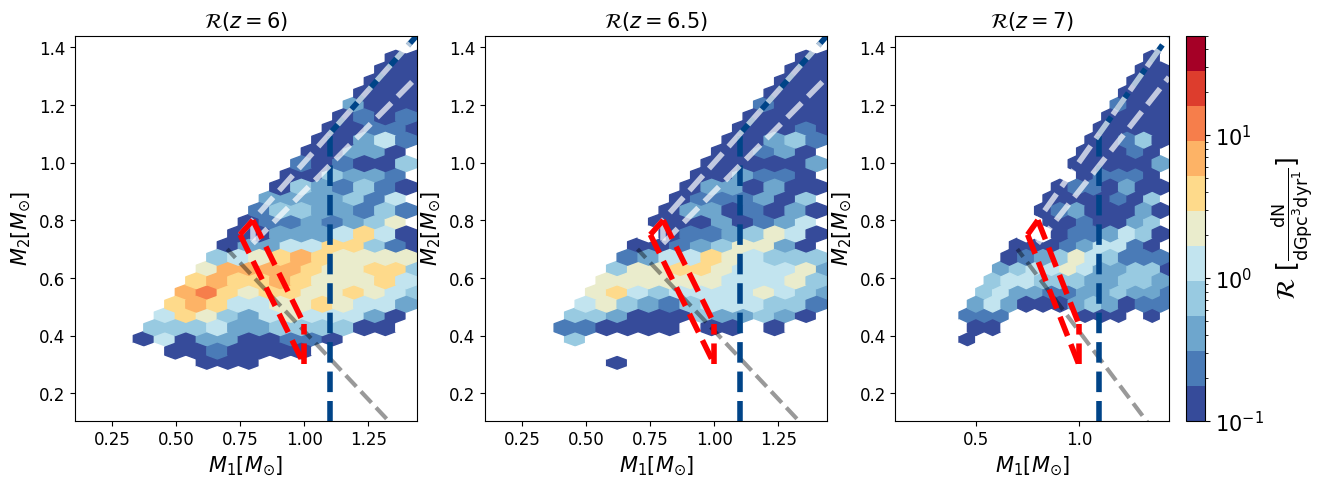

In [34]:
# DWD

fig, ax = plt.subplots(1,3, figsize = (15,5))

cset_c = tc.medium_contrast


vmin = 10**-1
vmax = 5*10

M1_COWD = M1_DWD[carbon_oxygen_bool_WDWD_merged_WDopt]
M2_COWD = M2_DWD[carbon_oxygen_bool_WDWD_merged_WDopt]

hb_6 = ax[0].hexbin(M1_COWD,M2_COWD,C=rates_WDWD_z6_COWD, gridsize=(15,15), reduce_C_function = np.sum, 
                    cmap="tol.sunset_discrete",norm='log',vmin=vmin,vmax=vmax) # C is how much each point is weighted

hb_65 = ax[1].hexbin(M1_COWD,M2_COWD,C=rates_WDWD_z65_COWD, gridsize=(15,15), reduce_C_function = np.sum, 
                    cmap="tol.sunset_discrete",norm='log',vmin=vmin,vmax=vmax) # C is how much each point is weighted

hb_7 = ax[2].hexbin(M1_COWD,M2_COWD,C=rates_WDWD_z7_COWD, gridsize=(15,15), reduce_C_function = np.sum, 
                    cmap="tol.sunset_discrete",norm='log',vmin=vmin,vmax=vmax) # C is how much each point is weighted

# cb_6 = plt.colorbar(hb_6)
# cb_6.set_label(label=r"$\mathcal{R}(z=7)$ [$\frac{\mathrm{dN}}{\mathrm{dGpc^{3}dyr^{1}}}$]", fontsize = 18)
# cb_6.ax.tick_params(labelsize=15)

# cb_65 = plt.colorbar(hb_65)
# cb_65.set_label(label=r"$\mathcal{R}(z=6.5)$ [$\frac{\mathrm{dN}}{\mathrm{dGpc^{3}dyr^{1}}}$]", fontsize = 18)
# cb_65.ax.tick_params(labelsize=15)

cb_7 = plt.colorbar(hb_7)
cb_7.set_label(label=r"$\mathcal{R}$ [$\frac{\mathrm{dN}}{\mathrm{dGpc^{3}dyr^{1}}}$]", fontsize = 18)
cb_7.ax.tick_params(labelsize=15)

max_mass_lim = 1.44

linecolors = 'white'
linewidths = 4


# # chandrasekar mass line
ax[0].plot((1.44,0.7),(0,0.7),color='black', lw=3, ls='--', alpha = 0.4)
# ax[0].annotate(r"$\rm{M}_{\rm{TOT}}>1.4\rm{M}_{\odot}$", xy=(0.75, 0.64), xytext=(0.45, 0.45), fontsize=11, color='black', arrowprops=dict(alpha=0.7,arrowstyle='->'))

# # violent merger - unequal
ax[0].vlines(x=[1.1], ymin=0, ymax=1.1, colors=cset_c.dark_blue, ls='--', lw=linewidths) # vertical line
ax[0].plot([1.1,max_mass_lim],[1.1,max_mass_lim],color=cset_c.dark_blue,lw=linewidths, ls='--') # horizontal line
# ax[0].annotate(r"Violent Merger - Unequal", xy=(1.25, 1), xytext=(0.65, 1.3), fontsize=11, color=cset_c.dark_blue, arrowprops=dict(color=cset_c.dark_blue,alpha=0.7,arrowstyle='->'))

# # violent merger - equal
ax[0].plot([0.75,max_mass_lim],[0.75,max_mass_lim],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # top boundary
ax[0].plot([0.8,max_mass_lim],[0.72,max_mass_lim*0.9],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # bottom boundary
ax[0].plot([0.8,0.8],[0.8,0.72],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # side boundary
# ax[0].annotate(r"Violent Merger - Equal", xy=(0.95, 0.9), xytext=(0.5, 1.1), fontsize=11, color='black', arrowprops=dict(color='black',alpha=0.7,arrowstyle='->'))

# Shen HVS SNe Ia
ax[0].plot([0.8,1],[0.8,0.44],color='red',ls='--', lw=4) # overlapping boundary
ax[0].plot([0.75,1.0],[0.75,0.3],'red', ls='--', lw=4) # bottom boundary
ax[0].plot([1.0,1.0],[0.3,0.44],'red', ls='--', lw=4) # side boundary
ax[0].plot([0.75,0.8],[0.75,0.8],'red',ls='--', lw=4) # top boundary
# ax[0].annotate(r"Shen 2025 $\mathrm{D^6}$ HVS", xy=(0.75, 0.77), xytext=(0.4, 0.85), fontsize=11, color='red', arrowprops=dict(color='red', alpha=0.7,arrowstyle='->'))





# # chandrasekar mass line
ax[1].plot((1.44,0.7),(0,0.7),color='black', lw=3, ls='--', alpha = 0.4)
# ax[1].annotate(r"$\rm{M}_{\rm{TOT}}>1.4\rm{M}_{\odot}$", xy=(0.75, 0.64), xytext=(0.45, 0.45), fontsize=15, color='black', arrowprops=dict(alpha=0.7,arrowstyle='->'))

# # violent merger - unequal
ax[1].vlines(x=[1.1], ymin=0, ymax=1.1, colors=cset_c.dark_blue, ls='--', lw=linewidths) # vertical line
ax[1].plot([1.1,max_mass_lim],[1.1,max_mass_lim],color=cset_c.dark_blue,lw=linewidths, ls='--') # horizontal line
# ax[1].annotate(r"Violent Merger - Unequal", xy=(1.25, 1), xytext=(0.65, 1.3), fontsize=11, color=cset_c.dark_blue, arrowprops=dict(color=cset_c.dark_blue,alpha=0.7,arrowstyle='->'))

# # violent merger - equal
ax[1].plot([0.75,max_mass_lim],[0.75,max_mass_lim],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # top boundary
ax[1].plot([0.8,max_mass_lim],[0.72,max_mass_lim*0.9],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # bottom boundary
ax[1].plot([0.8,0.8],[0.8,0.72],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # side boundary
# ax[1].annotate(r"Violent Merger - Equal", xy=(0.95, 0.9), xytext=(0.5, 1.1), fontsize=11, color='black', arrowprops=dict(color='black',alpha=0.7,arrowstyle='->'))

# Shen HVS SNe Ia
ax[1].plot([0.8,1],[0.8,0.44],color='red',ls='--', lw=4) # overlapping boundary
ax[1].plot([0.75,1.0],[0.75,0.3],'red', ls='--', lw=4) # bottom boundary
ax[1].plot([1.0,1.0],[0.3,0.44],'red', ls='--', lw=4) # side boundary
ax[1].plot([0.75,0.8],[0.75,0.8],'red',ls='--', lw=4) # top boundary
# ax[1].annotate(r"Shen 2025 $\mathrm{D^6}$ HVS", xy=(0.75, 0.77), xytext=(0.4, 0.85), fontsize=11, color='red', arrowprops=dict(color='red', alpha=0.7,arrowstyle='->'))




# # chandrasekar mass line
ax[2].plot((1.44,0.7),(0,0.7),color='black', lw=3, ls='--', alpha = 0.4)
# ax[2].annotate(r"$\rm{M}_{\rm{TOT}}>1.4\rm{M}_{\odot}$", xy=(0.75, 0.64), xytext=(0.45, 0.45), fontsize=11, color='black', arrowprops=dict(alpha=0.7,arrowstyle='->'))

# # violent merger - unequal
ax[2].vlines(x=[1.1], ymin=0, ymax=1.1, colors=cset_c.dark_blue, ls='--', lw=linewidths) # vertical line
ax[2].plot([1.1,max_mass_lim],[1.1,max_mass_lim],color=cset_c.dark_blue,lw=linewidths, ls='--') # horizontal line
# ax[2].annotate(r"Violent Merger - Unequal", xy=(1.25, 1), xytext=(0.65, 1.3), fontsize=11, color=cset_c.dark_blue, arrowprops=dict(color=cset_c.dark_blue,alpha=0.7,arrowstyle='->'))

# # violent merger - equal
ax[2].plot([0.75,max_mass_lim],[0.75,max_mass_lim],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # top boundary
ax[2].plot([0.8,max_mass_lim],[0.72,max_mass_lim*0.9],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # bottom boundary
ax[2].plot([0.8,0.8],[0.8,0.72],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # side boundary
# ax[2].annotate(r"Violent Merger - Equal", xy=(0.95, 0.9), xytext=(0.5, 1.1), fontsize=11, color='black', arrowprops=dict(color='black',alpha=0.7,arrowstyle='->'))

# Shen HVS SNe Ia
ax[2].plot([0.8,1],[0.8,0.44],color='red',ls='--', lw=4) # overlapping boundary
ax[2].plot([0.75,1.0],[0.75,0.3],'red', ls='--', lw=4) # bottom boundary
ax[2].plot([1.0,1.0],[0.3,0.44],'red', ls='--', lw=4) # side boundary
ax[2].plot([0.75,0.8],[0.75,0.8],'red',ls='--', lw=4) # top boundary
# ax[2].annotate(r"Shen 2025 $\mathrm{D^6}$ HVS", xy=(0.75, 0.77), xytext=(0.4, 0.85), fontsize=11, color='red', arrowprops=dict(color='red', alpha=0.7,arrowstyle='->'))



ax[0].set_ylim(min(M2_DWD),max_mass_lim)
ax[0].set_xlim(min(M2_DWD),max_mass_lim)
ax[0].set_xlabel("$M_{1}$[$M_{\odot}$]",fontsize=15)
ax[0].set_ylabel("$M_{2}$[$M_{\odot}$]",fontsize=15)
ax[0].tick_params(axis='both', labelsize=12)


ax[1].set_ylim(min(M2_DWD),max_mass_lim)
ax[1].set_xlim(min(M2_DWD),max_mass_lim)
ax[1].set_xlabel("$M_{1}$[$M_{\odot}$]",fontsize=15)
ax[1].set_ylabel("$M_{2}$[$M_{\odot}$]",fontsize=15)
ax[1].tick_params(axis='both', labelsize=12)


ax[2].set_ylim(min(M2_DWD),max_mass_lim)
ax[2].set_xlim(min(M2_DWD),max_mass_lim)
ax[2].set_xlabel("$M_{1}$[$M_{\odot}$]",fontsize=15)
ax[2].set_ylabel("$M_{2}$[$M_{\odot}$]",fontsize=15)
ax[2].tick_params(axis='both', labelsize=12)

# ax.set_title("Fiducial: DWD Mass Distribution", fontsize=15)

ax[0].set_title(r"$\mathcal{R}(z=6)$", fontsize=15)
ax[1].set_title(r"$\mathcal{R}(z=6.5)$", fontsize=15)
ax[2].set_title(r"$\mathcal{R}(z=7)$", fontsize=15)

## save figure:
# plt.savefig("../figures/mass_dist_DWD_z6_7.png",bbox_inches='tight',pad_inches=0.1)

### Let's investigate the hot spots + the plateau

Text(0.5, 1.0, 'Fiducial: DWD Mass Distribution')

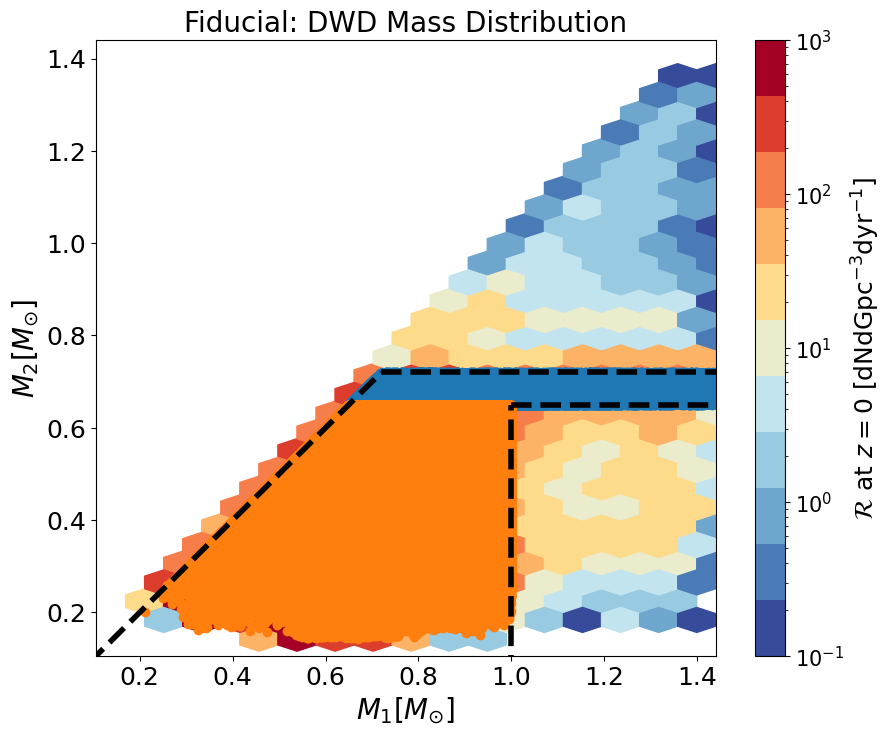

In [13]:
# DWD

fig, ax = plt.subplots(figsize = (10,8))

cset_c = tc.medium_contrast


vmin = 10**-1
vmax = 10**3

M1_COWD = M1_DWD[carbon_oxygen_bool_WDWD_merged_WDopt]
M2_COWD = M2_DWD[carbon_oxygen_bool_WDWD_merged_WDopt]

hb = ax.hexbin(M1_COWD,M2_COWD,C=rates_z0_merged_COWD, gridsize=(15,15), reduce_C_function = np.sum, 
                    cmap="tol.sunset_discrete",norm='log',vmin=vmin,vmax=vmax) # C is how much each point is weighted

cb = plt.colorbar(hb)
cb.set_label(label=r"$\mathcal{R}$ at $z=0$ [$\mathrm{dNdGpc^{-3}dyr^{-1}}$]", fontsize = 18)
cb.ax.tick_params(labelsize=15)

max_mass_lim = 1.44

# # # chandrasekar mass line
# ax.plot((1.44,0.7),(0,0.7),color='black', lw=3, ls='--', alpha = 0.4)
# ax.annotate(r"$\rm{M}_{\rm{TOT}}>1.4\rm{M}_{\odot}$", xy=(0.75, 0.64), xytext=(0.45, 0.45), fontsize=15, color='black', arrowprops=dict(alpha=0.7,arrowstyle='->'))

# # merging the most
top_boundary_bool = np.logical_and(M2_COWD<=0.72, M1_COWD>=M2_COWD)
tot_top_bool = np.logical_and(M2_COWD>0.65, top_boundary_bool)
bottom_boundary_bool = np.logical_and(M2_COWD<=0.65, M1_COWD>=M2_COWD)
tot_bottom_bool = np.logical_and(M1_COWD<=1.0, bottom_boundary_bool)
merging_local_bool = np.logical_or(tot_top_bool,tot_bottom_bool)

ax.scatter(M1_COWD[tot_top_bool], M2_COWD[tot_top_bool])
ax.scatter(M1_COWD[tot_bottom_bool], M2_COWD[tot_bottom_bool])
# print('top bool sum:',np.sum(tot_top_bool))
# print('bottom bool sum',np.sum(tot_bottom_bool))
# print('combined sum', np.sum(tot_top_bool)+np.sum(tot_bottom_bool))
# print('multiplied sum', np.sum(merging_local_bool))

ax.plot([0.72,max_mass_lim],[0.72,0.72],color='black',lw=linewidths, ls='--') # horizontal line
ax.plot([1.0,max_mass_lim],[0.65,0.65],color='black',lw=linewidths, ls='--') # horizontal line
ax.vlines(x=[1.0], ymin=0, ymax=0.65, colors='black', ls='--', lw=linewidths) # vertical line
ax.plot([0,0.72], [0, 0.72], color='black', ls='--', lw=linewidths)


ax.set_ylim(min(M2_DWD),max_mass_lim)
ax.set_xlim(min(M2_DWD),max_mass_lim)
ax.set_xlabel("$M_{1}$[$M_{\odot}$]",fontsize=20)
ax.set_ylabel("$M_{2}$[$M_{\odot}$]",fontsize=20)
ax.tick_params(axis='both', labelsize=18)

ax.set_title("Fiducial: DWD Mass Distribution", fontsize=20)

## save figure:
# plt.savefig("../figures/mass_dist_DWD_scenarios.png",bbox_inches='tight',pad_inches=0.1)

### we want where M1 < 1.0 and M2 < 0.7

In [14]:
# let's make a function to pick out our populous region
def merging_local_universe(mass1, mass2, carbon_oxygen_bool):

    # let's select the masses from the compas output
    mass_1_merged = mass1[carbon_oxygen_bool]
    mass_2_merged = mass2[carbon_oxygen_bool]
    
    M_more_massive = np.maximum(mass_1_merged,mass_2_merged)
    M_less_massive = np.minimum(mass_1_merged,mass_2_merged)
    
    top_bool = np.logical_and(np.logical_and(M_less_massive<=0.72, M_more_massive>=M_less_massive),
                              M_less_massive>0.65)
    bottom_bool = np.logical_and(np.logical_and(M_less_massive<=0.65, M_more_massive>=M_less_massive),
                                M_more_massive<=1.0)
    merging_local_bool = np.logical_or(top_bool, bottom_bool)

    return merging_local_bool


Now that we have our define region let's explore the parameter space of this group compared to the non-merging group

In [37]:
merging_local_bool = merging_local_universe(M1_DWD, M2_DWD, carbon_oxygen_bool_WDWD_merged_WDopt)
merging_index = np.where(merging_local_bool==1)[0]

non_merging_index = np.where(merging_local_bool==0)[0]
non_merging_local_bool = np.copy(merging_local_bool)
non_merging_local_bool[merging_index]=0
non_merging_local_bool[non_merging_index]=1

mixtrue_weights_merged_COWD = mixtrue_weights_merged_WDopt[carbon_oxygen_bool_WDWD_merged_WDopt]

print(merging_local_bool)
print(non_merging_local_bool)

[ True  True False ...  True  True  True]
[False False  True ... False False False]


In [52]:
# Let's first look at the separations

# gathering the masses
sep_all = DCOs_WDWD['SemiMajorAxis@DCO'][()]
sep_DCO = sep_all[DCO_mask_WDWD]
sep_merged = sep_DCO[condition_mergers_WDopt]
seps_merged_COWD = sep_merged[carbon_oxygen_bool_WDWD_merged_WDopt]
print(DCOs_WDWD['SemiMajorAxis@DCO'].attrs['units']) 

b'AU'


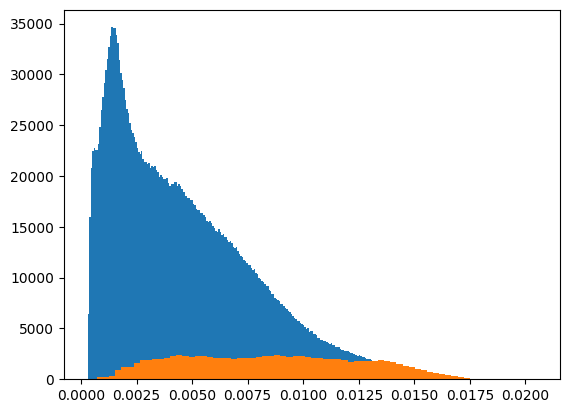

In [53]:
plt.hist(seps_merged_COWD[merging_local_bool], bins='auto');
plt.hist(seps_merged_COWD[non_merging_local_bool], bins='auto');

Text(0.5, 1.0, 'SemiMajor Axis Distributions')

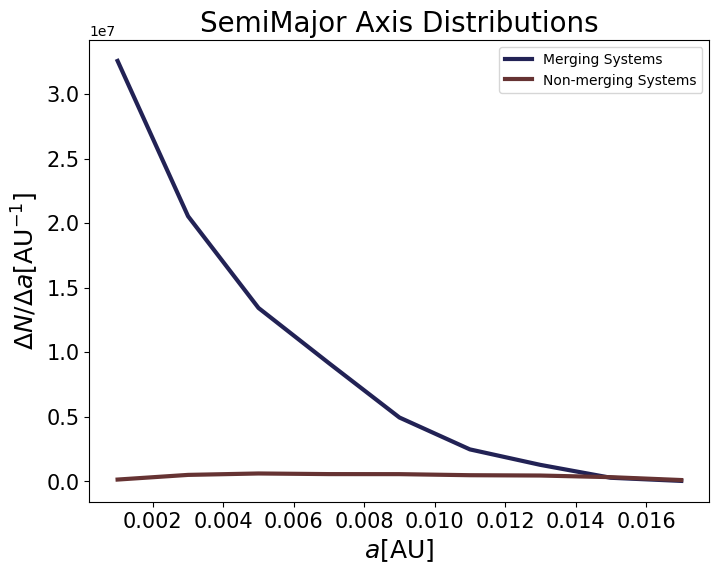

In [55]:
# plotting delay time dist
fig, axs = plt.subplots(figsize=(8, 6))

cset = tc.dark
cset_l = tc.light

# merging systems
bins_WDWD = np.arange(0,0.02,0.002)

hist, bin_edges = np.histogram(seps_merged_COWD[merging_local_bool], weights=mixtrue_weights_merged_COWD[merging_local_bool], bins = bins_WDWD, density=False)

binwidth = np.diff(bins_WDWD)
bin_centers = (bin_edges[0:-1] + bin_edges[1:])/2

axs.plot(bin_centers, (hist/binwidth), color=cset.dark_blue, lw=3, label='Merging Systems')


# non merging systems
hist_nm, bin_edges_nm = np.histogram(seps_merged_COWD[non_merging_local_bool], weights=mixtrue_weights_merged_COWD[non_merging_local_bool], bins = bins_WDWD, density=False)

binwidth_nm = np.diff(bins_WDWD)
bin_centers_nm = (bin_edges_nm[0:-1] + bin_edges_nm[1:])/2

axs.plot(bin_centers_nm, (hist_nm/binwidth_nm), color=cset.dark_red, lw=3, label='Non-merging Systems')



axs.set_ylabel(r'$\mathrm{\Delta} N/\mathrm{\Delta} a [\mathrm{AU}^{-1}]$', fontsize=18)
# axs[0].set_ylabel(r'Counts', fontsize=15)
axs.set_xlabel(r'$a[\mathrm{AU}]$', fontsize=18)
axs.tick_params(axis='both', labelsize=15)
axs.legend()

# axs.set_yscale('log')
# axs.set_xscale('log')
axs.legend(loc='upper right')

axs.set_title('SemiMajor Axis Distributions', fontsize=20)

# plt.subplots_adjust(wspace=0.4) # add padding between plots

## save figure:
# plt.savefig("../figures/delay_time_dist_log.png",bbox_inches='tight',pad_inches=0.1)

The merging systems have smaller separations than the non-merging systems in the local universe

In [51]:
DCOs_WDWD.keys()

<KeysViewHDF5 ['CE_Event_Counter', 'Coalescence_Time', 'Eccentricity@DCO', 'Immediate_RLOF>CE', 'MT_Donor_Hist(1)', 'MT_Donor_Hist(2)', 'Mass(1)', 'Mass(2)', 'Merges_Hubble_Time', 'Metallicity@ZAMS(1)', 'Optimistic_CE', 'Record_Type', 'Recycled_NS(1)', 'Recycled_NS(2)', 'SEED', 'SemiMajorAxis@DCO', 'Stellar_Type(1)', 'Stellar_Type(2)', 'Time', 'dmMT(1)', 'dmMT(2)', 'dmWinds(1)', 'dmWinds(2)', 'mixture_weight']>

In [56]:
# Let's first look at the separations

# gathering the masses
metals_all = DCOs_WDWD['Metallicity@ZAMS(1)'][()]
metals_DCO = metals_all[DCO_mask_WDWD]
metals_merged = metals_DCO[condition_mergers_WDopt]
metals_merged_COWD = metals_merged[carbon_oxygen_bool_WDWD_merged_WDopt]
print(DCOs_WDWD['Metallicity@ZAMS(1)'].attrs['units']) 

b'-'


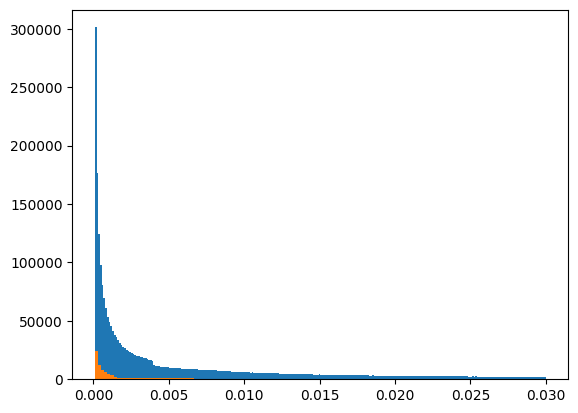

In [59]:
plt.hist(metals_merged_COWD[merging_local_bool], bins='auto');
plt.hist(metals_merged_COWD[non_merging_local_bool], bins='auto');

In [20]:
Data_NSNS.close()
Data_WDWD.close()